
IgG_1
Length: 220
Amino Acid Count: Counter({'S': 29, 'G': 23, 'V': 21, 'T': 19, 'L': 16, 'A': 16, 'P': 12, 'Y': 12, 'K': 11, 'N': 8, 'D': 8, 'Q': 7, 'R': 7, 'E': 6, 'F': 6, 'I': 5, 'W': 5, 'C': 4, 'H': 3, 'M': 2})

Mutated_IgG
Length: 220
Amino Acid Count: Counter({'S': 29, 'G': 23, 'V': 20, 'T': 20, 'A': 16, 'L': 15, 'P': 12, 'Y': 12, 'K': 11, 'N': 9, 'D': 8, 'Q': 7, 'R': 7, 'E': 6, 'F': 6, 'I': 5, 'W': 5, 'C': 4, 'H': 3, 'M': 2})

IgG_1
Hydrophobic: 83
Hydrophilic: 95

Mutated_IgG
Hydrophobic: 81
Hydrophilic: 97

Mutations (position, original, mutated):
Position: 10, Original: L, Mutated: N
Position: 11, Original: V, Mutated: T


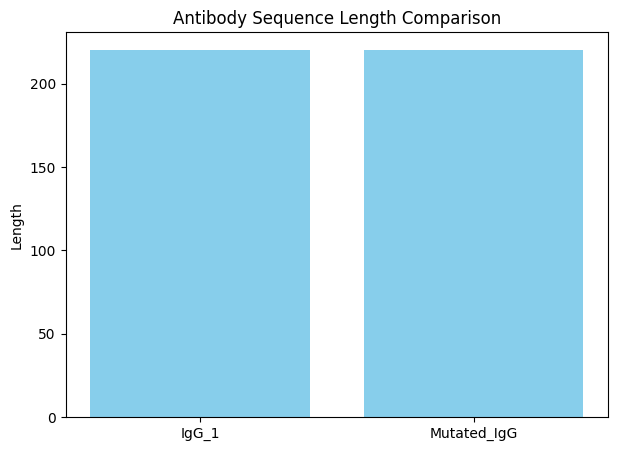

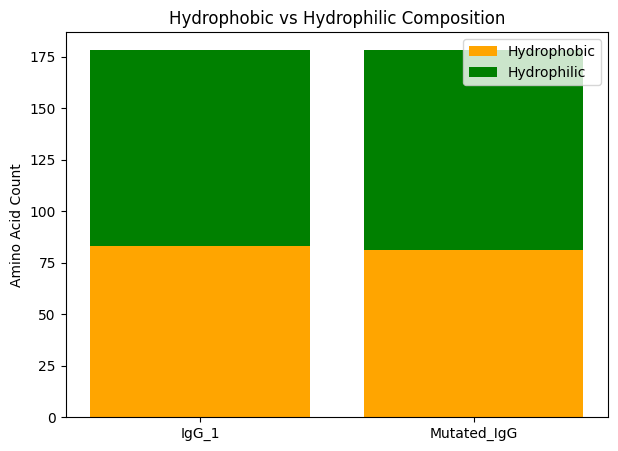

In [52]:
# Antibody Sequence Analysis

# Step 1: Import libraries for analysis and plotting

from collections import Counter
import matplotlib.pyplot as plt

# Step 2: Real Ab VH sequences (from NCBI)
# Sequence 1 : Trastuzumab
# Sequence 2 : Mutation

seq1 = ("""EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLEWVARIYPTNGYTRYADSVKGRFTI
SADTSKNTAYLQMNSLRAEDTAVYYCSRWGGDGFYAMDYWGQGTLVTVSSASTKGPSVFPLAPSSKSTSG
GTAALGCLVKDYFPEPVTVSWNSGALTSGVHTFPAVLQSSGLYSLSSVVTVPSSSLGTQTYICNVNHKPS
NTKVDKKVEP""").replace("\n", "")


# Step 3: Simulate a mutation

seq2 = seq1[:10] + "NT" + seq1[12:]

# Step 4: Organize sequences
sequences = {
    "IgG_1": seq1,
    "Mutated_IgG": seq2
}

# Step 5: Analyze sequences (length + amino acid count)
def analyze(seq):
    length = len(seq)
    count = Counter(seq)
    return length, count

results = {}

for name, seq in sequences.items():
    results[name] = analyze(seq)

# Step 6: Print analysis results
for name, (length, count) in results.items():
    print(f"\n{name}")
    print("Length:", length)
    print("Amino Acid Count:", count)

# Step 7: Hydrophobic vs Hydrophilic analysis
def hydropathy(seq):
    hydrophobic = ['A','V','I','L','M','F','W','Y']
    hydrophilic = ['R','N','D','Q','E','K','S','T']

    count = Counter(seq)

    hydro = sum(count[a] for a in hydrophobic if a in count)
    philic = sum(count[a] for a in hydrophilic if a in count)

    return hydro, philic

# Apply hydropathy and print
labels = []
hydro_values = []
philic_values = []

# Fill data
for name, seq in sequences.items():
    hydro, philic = hydropathy(seq)

    labels.append(name)
    hydro_values.append(hydro)
    philic_values.append(philic)

    print(f"\n{name}")
    print("Hydrophobic:", hydro)
    print("Hydrophilic:", philic)



# Step 8: Detect mutation positions
def find_mutation(seq1, seq2):
    mutations = []

    for i in range(min(len(seq1), len(seq2))):
        if seq1[i] != seq2[i]:
            mutations.append((i, seq1[i], seq2[i]))
    return mutations

mut = find_mutation(seq1,seq2)

print("\nMutations (position, original, mutated):")
for pos, original, mutated in mut:
    print(f"Position: {pos}, Original: {original}, Mutated: {mutated}")

# Step 9: Visualization
# 9a. Protein Length Comparison
labels = list(sequences.keys())
lengths = [results[name][0] for name in labels]

plt.figure(figsize=(7,5))
plt.bar(labels, lengths, color='skyblue')
plt.title("Antibody Sequence Length Comparison")
plt.ylabel("Length")
plt.show()

# 9b. Hydrophobic vs Hydrophilic stacked bar
plt.figure(figsize=(7,5))
plt.bar(labels, hydro_values, color='orange', label="Hydrophobic")
plt.bar(labels, philic_values, bottom=hydro_values, color='green', label="Hydrophilic")
plt.title("Hydrophobic vs Hydrophilic Composition")
plt.ylabel("Amino Acid Count")
plt.legend()
plt.show()

